# Beta Distribution

The **Beta distribution** is the most flexible distribution for data bounded to a fixed interval. With two shape parameters α and β, it can be uniform, U-shaped, J-shaped, bell-shaped, or skewed in either direction. It is the natural **conjugate prior** for Bernoulli/Binomial probabilities in Bayesian inference.

| Property | Value |
|---|---|
| **Parameters** | α (shape 1), β (shape 2), both > 0 |
| **Support** | [0, 1] (or [a, b] in general form) |
| **PDF** | f(x) = x^(α−1)(1−x)^(β−1) / B(α,β) |
| **Mean** | α/(α+β) |
| **Variance** | αβ / ((α+β)²(α+β+1)) |
| **Mode** | (α−1)/(α+β−2) for α,β > 1 |
| **Special cases** | α=β=1 → Uniform(0,1); α=β → symmetric |
| **Bayesian use** | Conjugate prior for p in Binomial: Beta(α+k, β+n−k) |

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

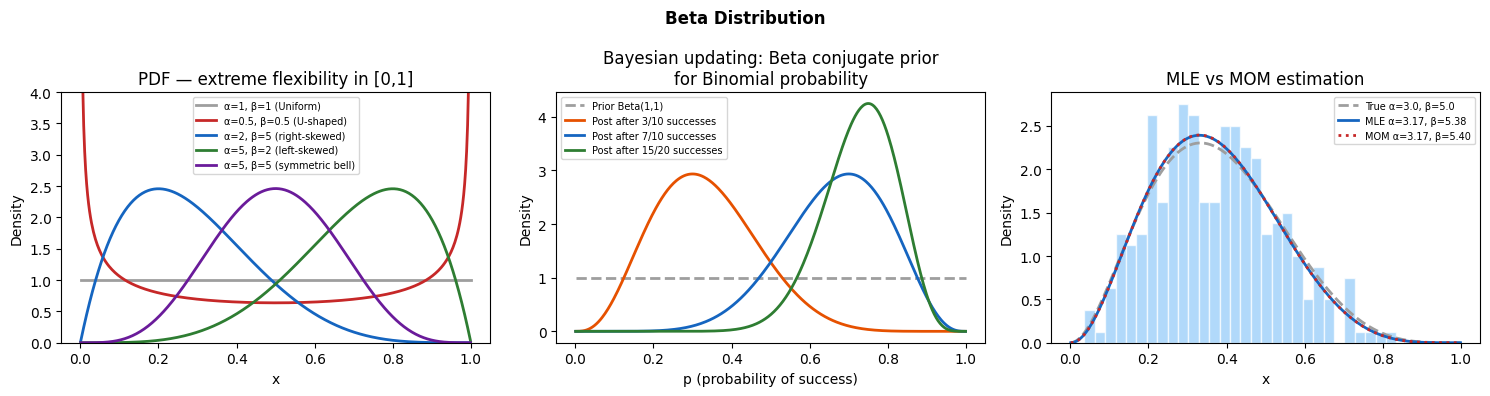

In [2]:
x = np.linspace(0.001, 0.999, 400)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Beta Distribution', fontsize=12, fontweight='bold')

# PDF — many shapes
for alpha, beta_p, color, label in [
    (1,   1,   '#9E9E9E', 'α=1, β=1 (Uniform)'),
    (0.5, 0.5, '#C62828', 'α=0.5, β=0.5 (U-shaped)'),
    (2,   5,   '#1565C0', 'α=2, β=5 (right-skewed)'),
    (5,   2,   '#2E7D32', 'α=5, β=2 (left-skewed)'),
    (5,   5,   '#6A1B9A', 'α=5, β=5 (symmetric bell)'),
]:
    axes[0].plot(x, stats.beta(alpha, beta_p).pdf(x), color=color, linewidth=2, label=label)
axes[0].set_title('PDF — extreme flexibility in [0,1]')
axes[0].set_xlabel('x'); axes[0].set_ylabel('Density')
axes[0].set_ylim(0, 4)
axes[0].legend(fontsize=7)

# Bayesian updating: Beta-Binomial conjugacy
# Prior: Beta(1,1) = Uniform
# Observe: k successes in n trials
alpha_prior, beta_prior = 1, 1
experiments = [(3, 10, '#E65100', '3/10 successes'),
               (7, 10, '#1565C0', '7/10 successes'),
               (15, 20, '#2E7D32', '15/20 successes')]
axes[1].plot(x, stats.beta(alpha_prior, beta_prior).pdf(x),
             color='#9E9E9E', linewidth=2, linestyle='--', label='Prior Beta(1,1)')
for k, n, color, label in experiments:
    alpha_post = alpha_prior + k
    beta_post  = beta_prior + (n - k)
    axes[1].plot(x, stats.beta(alpha_post, beta_post).pdf(x),
                 color=color, linewidth=2, label=f'Post after {label}')
axes[1].set_title('Bayesian updating: Beta conjugate prior\nfor Binomial probability')
axes[1].set_xlabel('p (probability of success)')
axes[1].set_ylabel('Density')
axes[1].legend(fontsize=7)

# MOM and MLE fit
np.random.seed(42)
true_a, true_b = 3.0, 5.0
data = stats.beta(true_a, true_b).rvs(300)

# MOM
m = data.mean(); v = data.var()
a_mom = m * (m*(1-m)/v - 1)
b_mom = (1-m) * (m*(1-m)/v - 1)

# MLE
a_mle, b_mle, _, _ = stats.beta.fit(data, floc=0, fscale=1)

axes[2].hist(data, bins=30, density=True, color='#90CAF9', edgecolor='white', alpha=0.7)
axes[2].plot(x, stats.beta(true_a, true_b).pdf(x),
             color='#9E9E9E', linewidth=2, linestyle='--', label=f'True α={true_a}, β={true_b}')
axes[2].plot(x, stats.beta(a_mle, b_mle).pdf(x),
             color='#1565C0', linewidth=2, label=f'MLE α={a_mle:.2f}, β={b_mle:.2f}')
axes[2].plot(x, stats.beta(a_mom, b_mom).pdf(x),
             color='#C62828', linewidth=2, linestyle=':', label=f'MOM α={a_mom:.2f}, β={b_mom:.2f}')
axes[2].set_title('MLE vs MOM estimation')
axes[2].set_xlabel('x'); axes[2].set_ylabel('Density')
axes[2].legend(fontsize=7)

plt.tight_layout()
plt.show()

## Key Takeaways

| | |
|---|---|
| **Bounded support** | Only continuous distribution naturally bounded to [0,1] |
| **Extreme flexibility** | Can be U-shaped, J-shaped, uniform, or any bell curve |
| **α=β** | Symmetric; as α=β→∞, converges to Normal |
| **α<1 or β<1** | J-shaped or U-shaped — probability concentrates at boundaries |
| **Conjugate prior** | Beta(α,β) prior + Binomial(k,n) likelihood → Beta(α+k, β+n−k) posterior |
| **Interpretation** | α−1 = prior successes, β−1 = prior failures |
| **Use cases** | Proportions, rates, probabilities, project completion fractions, A/B testing |